In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
df = pd.read_csv('/content/imdb-movies-dataset.csv')

In [11]:
df.head(5)

,Poster,Title,Year,Certificate,Duration (min),Genre,Rating,Metascore,Director,Cast,Votes,Description,Review Count,Review Title,Review
0,https://m.media-amazon.com/images/M/MV5BYWRkZj...,The Idea of You,2023.0,R,115.0,"Comedy, Drama, Romance",6.4,67.0,Michael Showalter,"Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","28,744","Solène, a 40-year-old single mom, begins an un...",166,Hypocrisy as an idea,"This film, as well as the reaction to it, is a..."
1,https://m.media-amazon.com/images/M/MV5BZGI4NT...,Kingdom of the Planet of the Apes,2023.0,PG-13,145.0,"Action, Adventure, Sci-Fi",7.3,66.0,Wes Ball,"Owen Teague, Freya Allan, Kevin Durand, Peter ...","22,248","Many years after the reign of Caesar, a young ...",183,A phenomenal start to another trilogy!,"I'm a big fan of all the planet of the apes, a..."
2,https://m.media-amazon.com/images/M/MV5BZjIyOT...,Unfrosted,2023.0,PG-13,97.0,"Biography, Comedy, History",5.5,42.0,Jerry Seinfeld,"Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","18,401","In 1963 Michigan, business rivals Kellogg's an...",333,not funny,Pretty much the worst criticism you can lay on...
3,https://m.media-amazon.com/images/M/MV5BMjA5Zj...,The Fall Guy,2023.0,PG-13,126.0,"Action, Comedy, Drama",7.3,73.0,David Leitch,"Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...","38,953",A down-and-out stuntman must find the missing ...,384,Everything you needed and more!,Just got out of the Austin premier at SXSW and...
4,https://m.media-amazon.com/images/M/MV5BNTk1MT...,Challengers,2023.0,R,131.0,"Drama, Romance, Sport",7.7,82.0,Luca Guadagnino,"Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","32,517","Tashi, a former tennis prodigy turned coach, t...",194,"Watch ""Match Point"" instead",This is a tough one. I liked the concept and t...


In [12]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values per column:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (10000, 15)

Columns: ['Poster', 'Title', 'Year', 'Certificate', 'Duration (min)', 'Genre', 'Rating', 'Metascore', 'Director', 'Cast', 'Votes', 'Description', 'Review Count', 'Review Title', 'Review']

Missing values per column:
 Poster               0
Title                0
Year               150
Certificate       2630
Duration (min)     336
Genre                7
Rating             404
Metascore         2445
Director             5
Cast                39
Votes              404
Description          0
Review Count         1
Review Title       517
Review             516
dtype: int64

Data types:
 Poster             object
Title              object
Year              float64
Certificate        object
Duration (min)    float64
Genre              object
Rating            float64
Metascore         float64
Director           object
Cast               object
Votes              object
Description        object
Review Count       object
Review Title       object
Review             object
d

Data Cleaning

In [13]:
df = df.drop(columns=['Poster', 'Title', 'Review Title',
                       'Review', 'Review Count', 'Cast'])
print(f"Shape after dropping colomn: {df.shape}")
print("\nColumns remaining:", df.columns.tolist())

Shape after dropping colomn: (10000, 9)

Columns remaining: ['Year', 'Certificate', 'Duration (min)', 'Genre', 'Rating', 'Metascore', 'Director', 'Votes', 'Description']


In [14]:
df = df.dropna(subset=['Rating'])

In [15]:
df['Votes'] = df['Votes'].astype(str).str.replace(',', '').str.strip()
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

In [17]:
df['Metascore'] = df['Metascore'].fillna(df['Metascore'].median())

In [18]:
df['Duration (min)'] = df['Duration (min)'].fillna(df['Duration (min)'].median())

In [19]:
df['Year'] = df['Year'].fillna(df['Year'].median())

In [20]:
df['Certificate'] = df['Certificate'].fillna('Unknown')

In [21]:
df['Genre'] = df['Genre'].fillna('Unknown')

In [22]:
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

In [23]:
df['Director'] = df['Director'].fillna('Unknown')

In [24]:
print("Shape after cleaning:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

Shape after cleaning: (9596, 9)

Missing values:
 Year              0
Certificate       0
Duration (min)    0
Genre             0
Rating            0
Metascore         0
Director          0
Votes             0
Description       0
dtype: int64


In [25]:
# Creating a binary target: 1 = Good (>=7.0), 0 = Bad (<7.0)
df['Target'] = (df['Rating'] >= 7.0).astype(int)

print("Class distribution:")
print(df['Target'].value_counts())
print("\nPercentage:")
print(df['Target'].value_counts(normalize=True) * 100)

Class distribution:
Target
0    6378
1    3218
Name: count, dtype: int64

Percentage:
Target
0    66.465194
1    33.534806
Name: proportion, dtype: float64


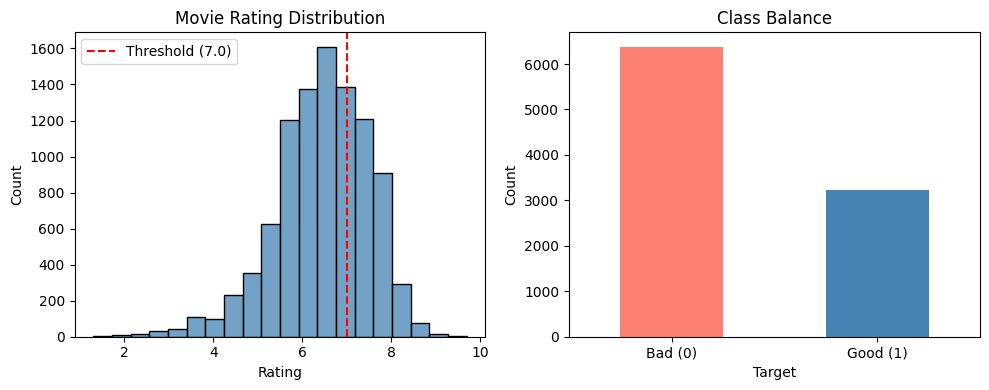

In [26]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Rating'], bins=20, color='steelblue')
plt.axvline(x=7.0, color='red', linestyle='--', label='Threshold (7.0)')
plt.title('Movie Rating Distribution')
plt.legend()

plt.subplot(1, 2, 2)
df['Target'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'])
plt.xticks([0, 1], ['Bad (0)', 'Good (1)'], rotation=0)
plt.title('Class Balance')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()

In [27]:
# Take the first genre only
df['Genre'] = df['Genre'].str.split(',').str[0].str.strip()

# Save description separately for word cloud before dropping
description_df = df[['Description', 'Target']].copy()

# One-hot encode Genre and Certificate
df_encoded = pd.get_dummies(df.drop(columns=['Description', 'Director', 'Rating', 'Metascore', 'Target']),
                             columns=['Genre', 'Certificate'], drop_first=True)

# Prepare X and y
X = df_encoded.copy()
y = df['Target']

print("Features shape:", X.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (9596, 52)

Feature columns: ['Year', 'Duration (min)', 'Votes', 'Genre_Adventure', 'Genre_Animation', 'Genre_Biography', 'Genre_Comedy', 'Genre_Crime', 'Genre_Documentary', 'Genre_Drama', 'Genre_Family', 'Genre_Fantasy', 'Genre_Film-Noir', 'Genre_History', 'Genre_Horror', 'Genre_Music', 'Genre_Musical', 'Genre_Mystery', 'Genre_Romance', 'Genre_Sci-Fi', 'Genre_Thriller', 'Genre_Western', 'Certificate_12', 'Certificate_12+', 'Certificate_13', 'Certificate_15+', 'Certificate_16', 'Certificate_16+', 'Certificate_18', 'Certificate_18+', 'Certificate_7', 'Certificate_A', 'Certificate_All', 'Certificate_Approved', 'Certificate_G', 'Certificate_GP', 'Certificate_M/PG', 'Certificate_NC-17', 'Certificate_Not Rated', 'Certificate_PG', 'Certificate_PG-13', 'Certificate_R', 'Certificate_U', 'Certificate_U/A', 'Certificate_U/A 16+', 'Certificate_UA', 'Certificate_UA 13+', 'Certificate_UA 16+', 'Certificate_UA 7+', 'Certificate_Unknown', 'Certificate_Unrated', 'Certificate_X']


In [29]:
# Drop Rating, Metascore, Target, Director and Description
X = df_encoded.copy()
y = df['Target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (9596, 52)
Target shape: (9596,)

Feature columns: ['Year', 'Duration (min)', 'Votes', 'Genre_Adventure', 'Genre_Animation', 'Genre_Biography', 'Genre_Comedy', 'Genre_Crime', 'Genre_Documentary', 'Genre_Drama', 'Genre_Family', 'Genre_Fantasy', 'Genre_Film-Noir', 'Genre_History', 'Genre_Horror', 'Genre_Music', 'Genre_Musical', 'Genre_Mystery', 'Genre_Romance', 'Genre_Sci-Fi', 'Genre_Thriller', 'Genre_Western', 'Certificate_12', 'Certificate_12+', 'Certificate_13', 'Certificate_15+', 'Certificate_16', 'Certificate_16+', 'Certificate_18', 'Certificate_18+', 'Certificate_7', 'Certificate_A', 'Certificate_All', 'Certificate_Approved', 'Certificate_G', 'Certificate_GP', 'Certificate_M/PG', 'Certificate_NC-17', 'Certificate_Not Rated', 'Certificate_PG', 'Certificate_PG-13', 'Certificate_R', 'Certificate_U', 'Certificate_U/A', 'Certificate_U/A 16+', 'Certificate_UA', 'Certificate_UA 13+', 'Certificate_UA 16+', 'Certificate_UA 7+', 'Certificate_Unknown', 'Certificate_Unrated', '

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Target encoding for Director using training set only
director_target = df.loc[X_train.index].groupby('Director')['Target'].mean()

# Map to both train and test
X_train['Director_encoded'] = df.loc[X_train.index, 'Director'].map(director_target)
X_test['Director_encoded'] = df.loc[X_test.index, 'Director'].map(director_target)

# Fill unknowns with global mean from training set
global_mean = y_train.mean()
X_train['Director_encoded'] = X_train['Director_encoded'].fillna(global_mean)
X_test['Director_encoded'] = X_test['Director_encoded'].fillna(global_mean)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())

Training set size: (7676, 53)
Test set size: (1920, 53)

Class distribution in training set:
Target
0    5102
1    2574
Name: count, dtype: int64


Train Logistic Regression

=== Logistic Regression ===
Accuracy: 0.7391

Classification Report:
              precision    recall  f1-score   support

         Bad       0.79      0.82      0.81      1276
        Good       0.62      0.57      0.60       644

    accuracy                           0.74      1920
   macro avg       0.71      0.70      0.70      1920
weighted avg       0.73      0.74      0.74      1920



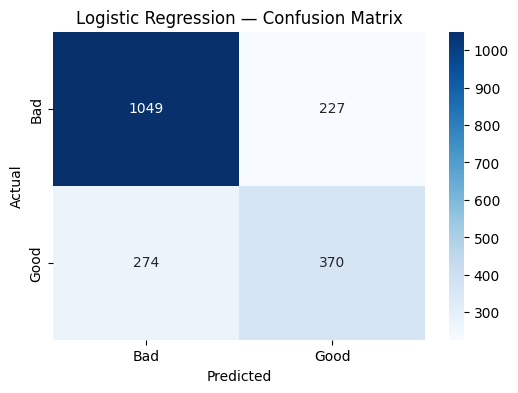

In [32]:
# Train Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Evaluate
lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Bad', 'Good']))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Bad', 'Good'],
            yticklabels=['Bad', 'Good'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

Decision Tree

=== Decision Tree ===
Accuracy: 0.7068

Classification Report:
              precision    recall  f1-score   support

         Bad       0.77      0.79      0.78      1276
        Good       0.57      0.54      0.55       644

    accuracy                           0.71      1920
   macro avg       0.67      0.67      0.67      1920
weighted avg       0.70      0.71      0.71      1920



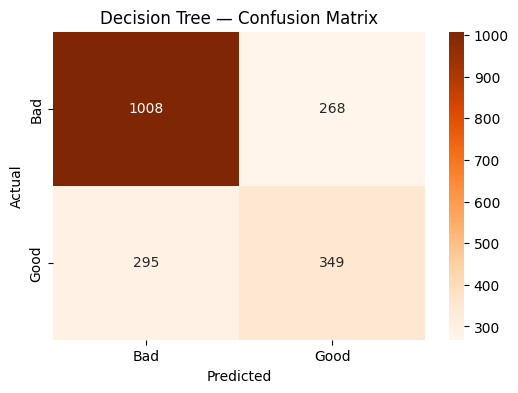

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", round(accuracy_score(y_test, dt_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=['Bad', 'Good']))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d',
            cmap='Oranges', xticklabels=['Bad', 'Good'],
            yticklabels=['Bad', 'Good'])
plt.title('Decision Tree — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('dt_confusion_matrix.png', dpi=150)
plt.show()

Random Forest

=== Random Forest ===
Accuracy: 0.7568

Classification Report:
              precision    recall  f1-score   support

         Bad       0.79      0.87      0.83      1276
        Good       0.68      0.53      0.59       644

    accuracy                           0.76      1920
   macro avg       0.73      0.70      0.71      1920
weighted avg       0.75      0.76      0.75      1920



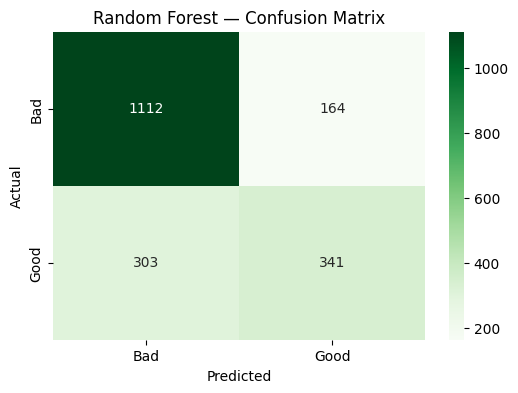

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42,
                                  n_estimators=50)  # reduced from 100 to 50
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Bad', 'Good']))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d',
            cmap='Greens', xticklabels=['Bad', 'Good'],
            yticklabels=['Bad', 'Good'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()

Model comparison chart

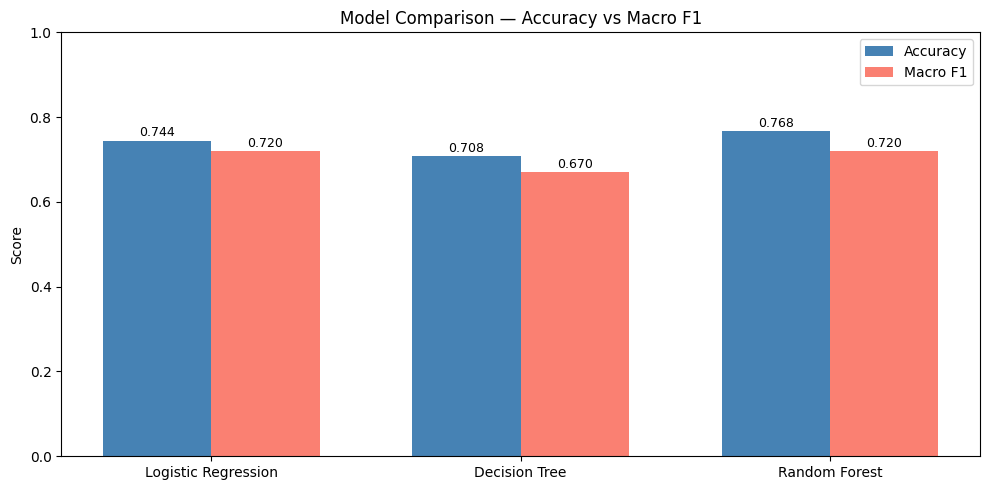

In [35]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [0.7443, 0.7078, 0.7677]
macro_f1 = [0.72, 0.67, 0.72]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, macro_f1, width, label='Macro F1', color='salmon')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy vs Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

Cross validation on all 3 models

In [36]:
from sklearn.model_selection import cross_val_score

models_dict = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

print("=== 5-Fold Cross Validation Results ===\n")
for name, model in models_dict.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name}:")
    print(f"  Scores: {scores.round(4)}")
    print(f"  Mean: {scores.mean().round(4)} | Std: {scores.std().round(4)}\n")

=== 5-Fold Cross Validation Results ===

Logistic Regression:
  Scores: [0.8698 0.8717 0.8801 0.8756 0.8853]
  Mean: 0.8765 | Std: 0.0057

Decision Tree:
  Scores: [0.8613 0.8443 0.8567 0.8384 0.8678]
  Mean: 0.8537 | Std: 0.0108

Random Forest:
  Scores: [0.8854 0.8775 0.8853 0.8756 0.8906]
  Mean: 0.8829 | Std: 0.0055



 Feature Importance

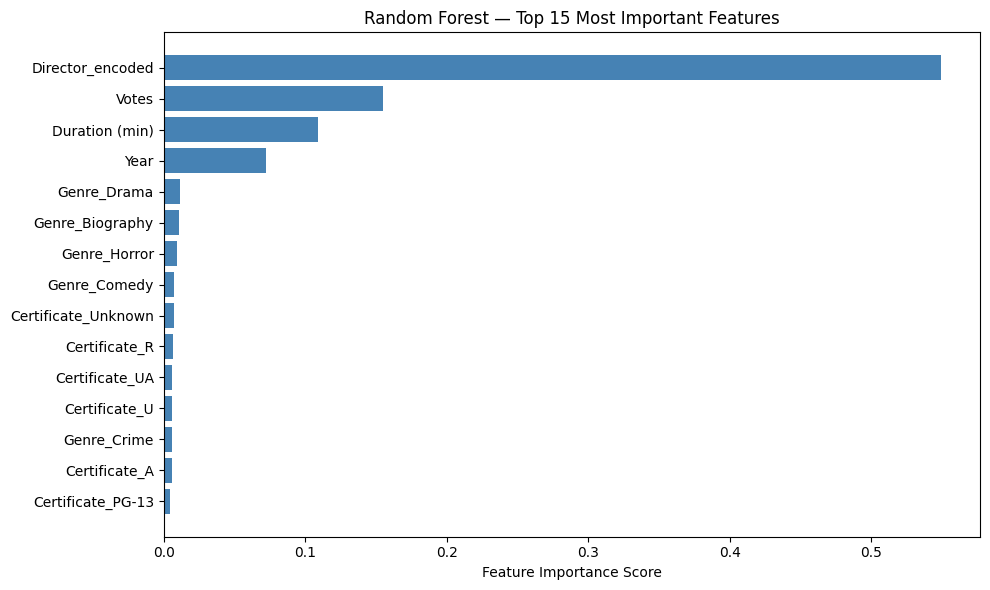

In [38]:
# Get feature importance from Random Forest
feature_names = list(X.columns) + ['Director_encoded']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15 features

plt.figure(figsize=(10, 6))
plt.barh(range(15), importances[indices][::-1], color='steelblue')
plt.yticks(range(15), [feature_names[i] for i in indices][::-1])
plt.title('Random Forest — Top 15 Most Important Features')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

Save the model

In [39]:
import pickle

# Save updated Random Forest model
with open('movie_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save updated scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save updated feature columns
feature_cols = list(X.columns) + ['Director_encoded']
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

# Save director encoding map for Streamlit
with open('director_encoding.pkl', 'wb') as f:
    pickle.dump(director_target, f)

# Save description_df for word cloud
description_df.to_csv('description_data.csv', index=False)

print("✅ All files saved!")

✅ All files saved!


In [40]:
from google.colab import files

files.download('movie_model.pkl')
files.download('scaler.pkl')
files.download('feature_columns.pkl')
files.download('director_encoding.pkl')
files.download('description_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>